In [27]:
import pandas as pd
import numpy as np
import seaborn as sns


pd.set_option('display.max_columns', None)

# Replace with your actual file paths
train_path = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\train.csv"
val_path = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\validate.csv"
test_path = r"C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\test.csv"


def load_and_inspect_data(file_path):
    df = pd.read_csv(file_path)
    print(f"Data loaded: {file_path}")
    print("=====================================")
    print("First 3 rows:")
    print(df.head(3))
    print("\nSummary:")
    print(f"Total samples: {len(df)}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Unique classes: {df['class'].nunique()}")
    print(f"Class distribution:\n{df['class'].value_counts()}")
    return df

print("===== Training Data =====")
train_df = load_and_inspect_data(train_path)
print("\n===== Validation Data =====")
val_df = load_and_inspect_data(val_path)
print("\n===== Test Data =====")
test_df = load_and_inspect_data(test_path)

===== Training Data =====
Data loaded: C:\Users\kaush\Music\asl\MS-ASL\asl_landmarks_output\train.csv
First 3 rows:
              video_id    class  frame  Face_LM_0_x  Face_LM_0_y  Face_LM_0_z  \
0  -DZaI_yoNac_teacher  teacher      0     0.501489     0.291855    -0.929792   
1  -DZaI_yoNac_teacher  teacher      1     0.488614     0.272328    -1.150703   
2  -DZaI_yoNac_teacher  teacher      2     0.488635     0.252779    -0.989913   

   Face_LM_1_x  Face_LM_1_y  Face_LM_1_z  Face_LM_2_x  Face_LM_2_y  \
0     0.517985     0.231718    -0.873637     0.528615     0.232628   
1     0.505778     0.221172    -0.946698     0.515470     0.221179   
2     0.501130     0.210595    -0.940724     0.511051     0.210875   

   Face_LM_2_z  Face_LM_3_x  Face_LM_3_y  Face_LM_3_z  Face_LM_4_x  \
0    -0.874234     0.537620     0.232598    -0.874125     0.486751   
1    -0.947844     0.527936     0.222422    -0.945728     0.472796   
2    -0.941504     0.521210     0.210973    -0.941397     0.470316  

In [28]:
import pandas as pd

def status_checker(df):
    print(df.describe())
    min_values = df.min()
    max_values = df.max()
    print("Minimum values of each column:")
    print(min_values)
    print("Maximum values of each column:")
    print(max_values)
    
dfs = [train_df, val_df, test_df]

for i in dfs:
    status_checker(i)
    print("="*150)


              frame   Face_LM_0_x   Face_LM_0_y   Face_LM_0_z   Face_LM_1_x  \
count  27388.000000  27388.000000  27388.000000  27388.000000  27388.000000   
mean    4224.760187      0.518467      0.288558     -0.548879      0.534368   
std     5735.209993      0.057693      0.083150      0.290462      0.057249   
min        0.000000      0.000000      0.000000     -2.282733      0.000000   
25%      126.000000      0.488015      0.239314     -0.687708      0.504729   
50%     2342.000000      0.518523      0.277161     -0.503969      0.534708   
75%     5884.000000      0.543979      0.327679     -0.344246      0.561885   
max    33848.000000      0.712847      0.790314      0.728005      0.721686   

        Face_LM_1_y   Face_LM_1_z   Face_LM_2_x   Face_LM_2_y   Face_LM_2_z  \
count  27388.000000  27388.000000  27388.000000  27388.000000  27388.000000   
mean       0.245809     -0.508753      0.545891      0.246859     -0.509346   
std        0.084285      0.276077      0.057481    

In [26]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [29]:
for i in dfs:
    print(i.groupby("video_id")["frame"].count())
    print("="*40)

video_id
-DZaI_yoNac_teacher     93
-LB4ENHxcIs_deaf        67
-LB4ENHxcIs_no          63
-LB4ENHxcIs_teacher     67
02NAI-ykpWk_orange     293
                      ... 
y3Vd7SZ_bp4_nice        52
yDNcxRM9Nf8_no          92
yG09SQB0Hds_hello       30
yRFpGRVjGxo_deaf        72
yYmiLJpJocA_nice        87
Name: frame, Length: 269, dtype: int64
video_id
0HvgswZfDGI_no               35
0bIF7jh6lnE_deaf             48
0bIF7jh6lnE_no               28
0bIF7jh6lnE_teacher          42
0qeMFifNqC4_like             90
1bj72qXSy8c_like             75
1bj72qXSy8c_nice             82
7bWO4SJ0sv4_happy            44
9g-hioQapYE_deaf             43
9g-hioQapYE_hello            46
9g-hioQapYE_nice             39
9g-hioQapYE_orange           48
9g-hioQapYE_teacher          41
9g-hioQapYE_want             46
BEKUHzwnVO8_deaf             70
BEKUHzwnVO8_hello           184
BEKUHzwnVO8_nice            189
BEKUHzwnVO8_no              181
BEKUHzwnVO8_teacher         121
CmKYKBQuHf4_eat             194
CxTSVy

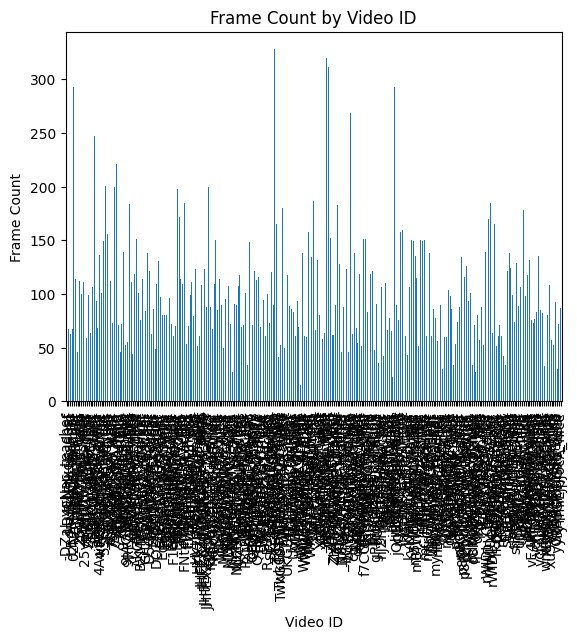

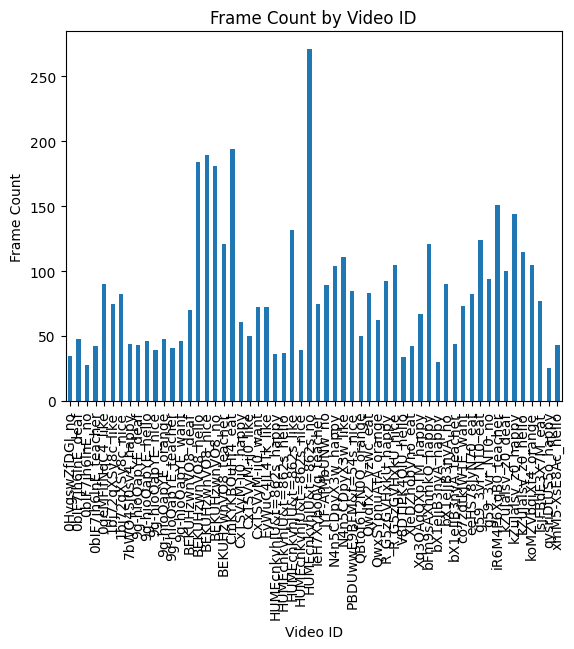

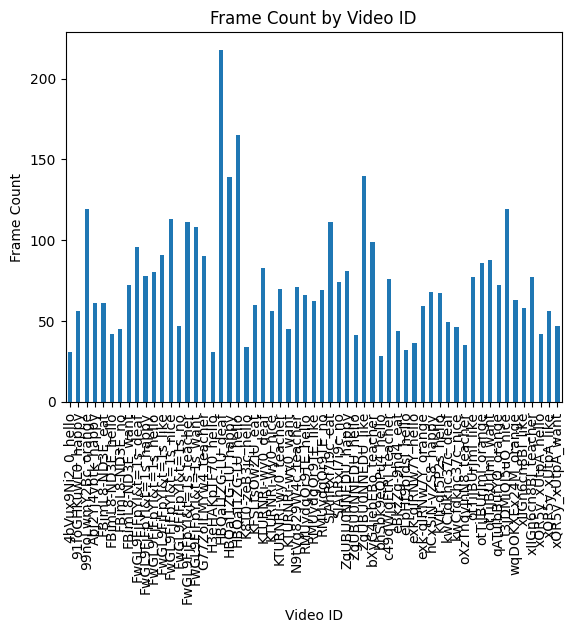

In [30]:
import matplotlib.pyplot as plt

for i in dfs:
    frame_counts = i.groupby("video_id")["frame"].count()
    frame_counts.plot(kind='bar')
    plt.title("Frame Count by Video ID")
    plt.xlabel("Video ID")
    plt.ylabel("Frame Count")
    plt.show()
    print("="*40)


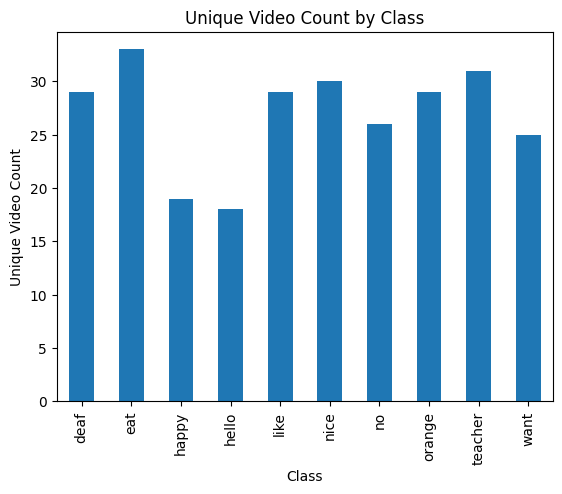

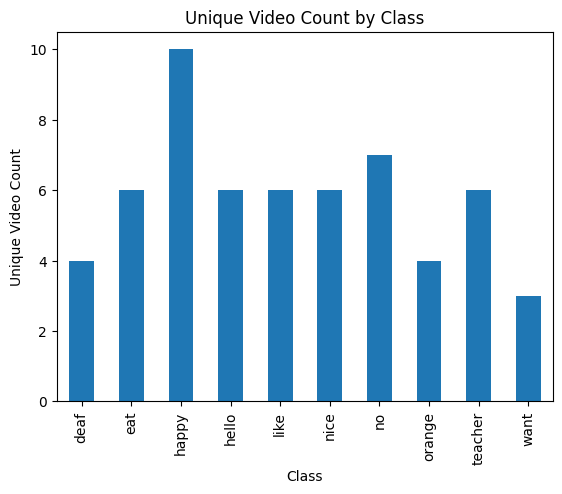

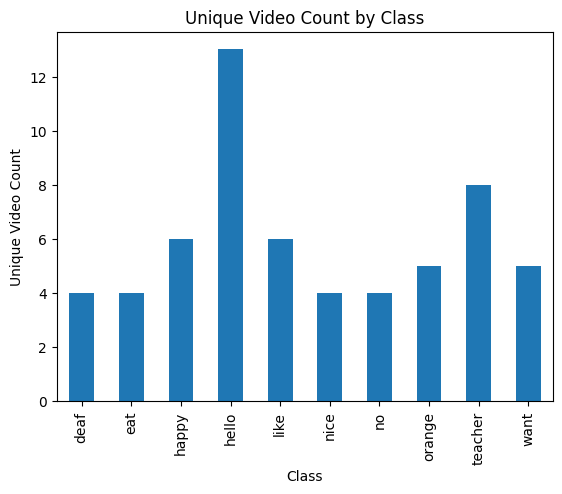

In [31]:


# Create a chart for each DataFrame
for i in dfs:
    unique_video_counts = i.groupby("class")["video_id"].nunique()
    unique_video_counts.plot(kind='bar')
    plt.title("Unique Video Count by Class")
    plt.xlabel("Class")
    plt.ylabel("Unique Video Count")
    plt.show()
    print("="*100)


In [34]:
def detect_outliers(df, name="dataset", method='iqr', class_column='class', 
                   output_plots=False, save_outliers=False, 
                   ignore_zero_columns=True, z_threshold=3, iqr_multiplier=1.5):
    """
    Detect outliers in landmark coordinate data from a DataFrame.
    
    Parameters:
    - df (DataFrame): Input DataFrame containing the data
    - name (str): Name of the dataset (for reporting)
    - method (str): 'iqr', 'zscore', or 'range' (default: 'iqr')
    - class_column (str): Column name for grouping (default: 'class')
    - output_plots (bool): Whether to generate visualizations (default: False)
    - save_outliers (bool): Whether to save outliers to CSV (default: False)
    - ignore_zero_columns (bool): Whether to ignore all-zero columns (default: True)
    - z_threshold (float): Z-score threshold (default: 3)
    - iqr_multiplier (float): IQR multiplier (default: 1.5)
    
    Returns:
    - dict: Dictionary containing outliers DataFrame and summary statistics
    """
    
    # Identify coordinate columns
    coordinate_cols = [col for col in df.columns if col.endswith(('_x', '_y', '_z'))]
    
    # Ignore all-zero columns if requested
    if ignore_zero_columns:
        non_zero_cols = df[coordinate_cols].columns[(df[coordinate_cols] != 0).any()]
        coordinate_cols = [col for col in coordinate_cols if col in non_zero_cols]
    
    results = {
        'dataset_name': name,
        'total_rows': len(df),
        'coordinate_columns': coordinate_cols,
        'outliers_detected': None,
        'outliers_by_class': {}
    }
    
    # Method 1: Range-based detection
    if method == 'range':
        outliers = df[(df[coordinate_cols] < 0) | (df[coordinate_cols] > 1)]
        results['method'] = 'Range (0-1)'
    
    # Method 2: Z-score detection
    elif method == 'zscore':
        z_scores = df[coordinate_cols].apply(zscore)
        outliers = df[(z_scores.abs() > z_threshold).any(axis=1)]
        results['method'] = f'Z-score (threshold={z_threshold})'
    
    # Method 3: IQR detection (default)
    else:
        Q1 = df[coordinate_cols].quantile(0.25)
        Q3 = df[coordinate_cols].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        outliers = df[(df[coordinate_cols] < lower_bound) | (df[coordinate_cols] > upper_bound)].dropna()
        results['method'] = f'IQR (multiplier={iqr_multiplier})'
    
    results['outliers_detected'] = len(outliers)
    results['outliers_percentage'] = (len(outliers) / len(df)) * 100
    
    # Group outliers by class if class column exists
    if class_column in df.columns:
        grouped = df.groupby(class_column)
        for group_name, group in grouped:
            if method == 'zscore':
                z_scores = group[coordinate_cols].apply(zscore)
                class_outliers = group[(z_scores.abs() > z_threshold).any(axis=1)]
            else:
                Q1 = group[coordinate_cols].quantile(0.25)
                Q3 = group[coordinate_cols].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - iqr_multiplier * IQR
                upper_bound = Q3 + iqr_multiplier * IQR
                class_outliers = group[(group[coordinate_cols] < lower_bound) | 
                                      (group[coordinate_cols] > upper_bound)].dropna()
            
            results['outliers_by_class'][group_name] = {
                'count': len(class_outliers),
                'percentage': (len(class_outliers) / len(group)) * 100,
                'examples': class_outliers.head(3).to_dict('records')
            }
    
    # Generate visualizations
    if output_plots and coordinate_cols:
        plt.figure(figsize=(12, 6))
        
        # Boxplot for first 3 coordinate columns
        sns.boxplot(data=df[coordinate_cols[:3]])
        plt.title(f'Distribution of Coordinates ({name})\n({results["method"]})')
        plt.xticks(rotation=45)
        plt.show()
        
        # Scatter plot for first x-y pair if available
        if len(coordinate_cols) >= 2:
            x_col = next((col for col in coordinate_cols if col.endswith('_x')), None)
            y_col = next((col for col in coordinate_cols if col.endswith('_y')), None)
            if x_col and y_col:
                plt.figure(figsize=(10, 8))
                sns.scatterplot(data=df, x=x_col, y=y_col, 
                               hue=class_column if class_column in df.columns else None,
                               alpha=0.6)
                plt.title(f'{name}: Coordinate Space - {x_col} vs {y_col}')
                plt.show()
    
    # Save outliers to file
    if save_outliers and len(outliers) > 0:
        output_file = f"{name}_outliers_{method}.csv"
        outliers.to_csv(output_file, index=False)
        results['output_file'] = output_file
    
    return {'results': results, 'outliers_df': outliers}


Analyzing train dataset...


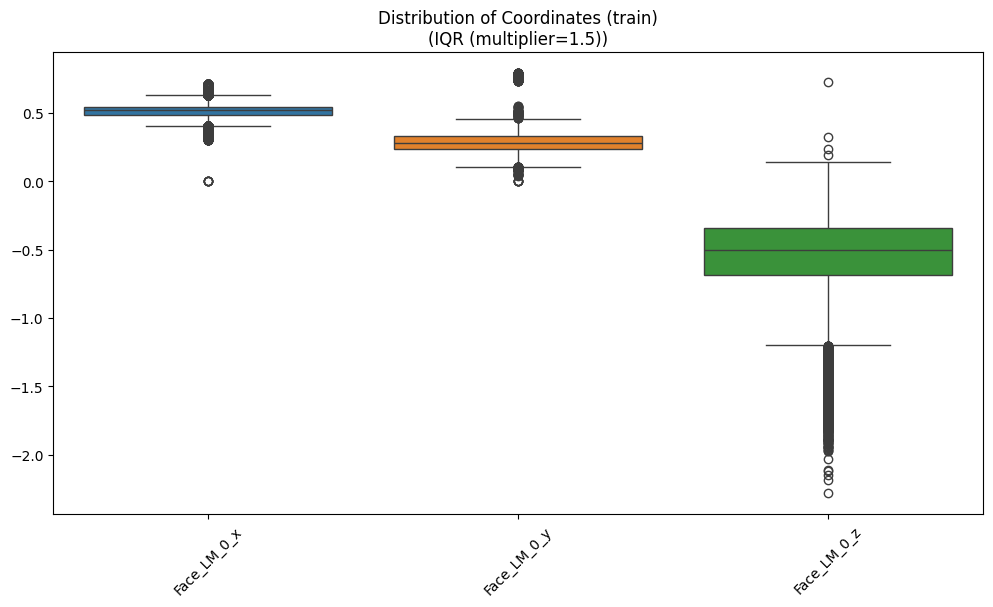

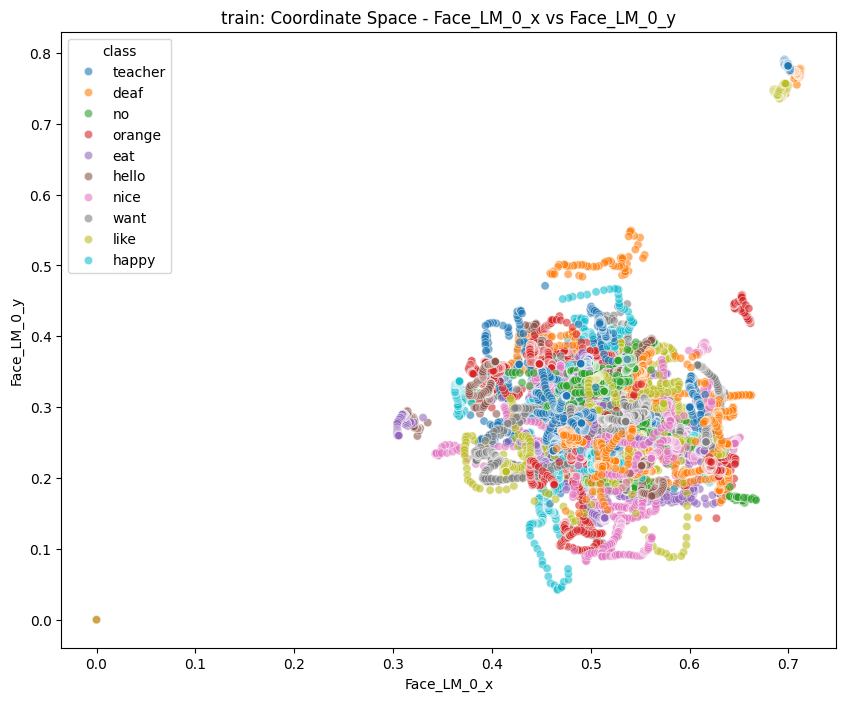

Found 0 outliers (0.00%)

Analyzing val dataset...


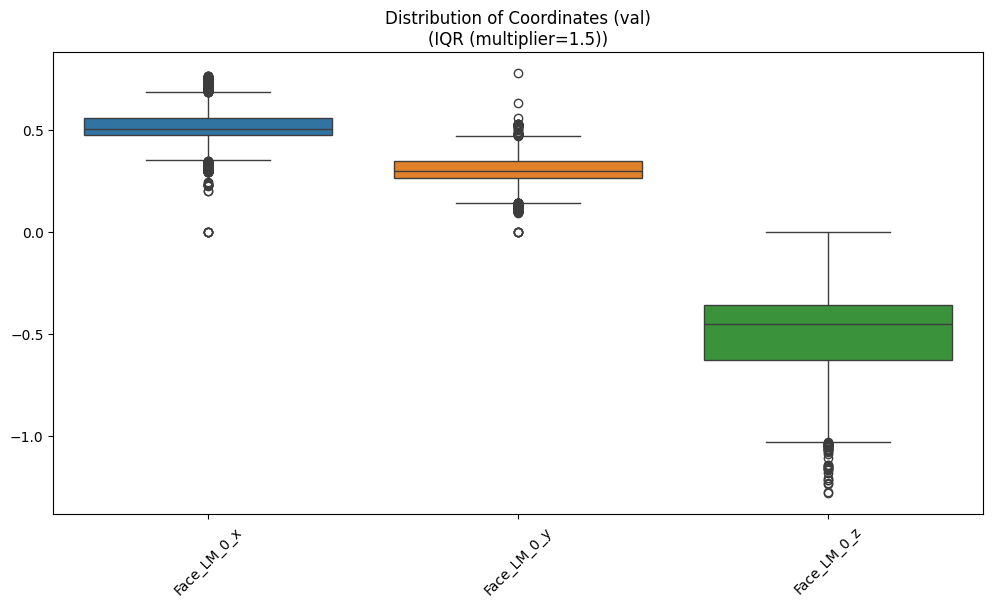

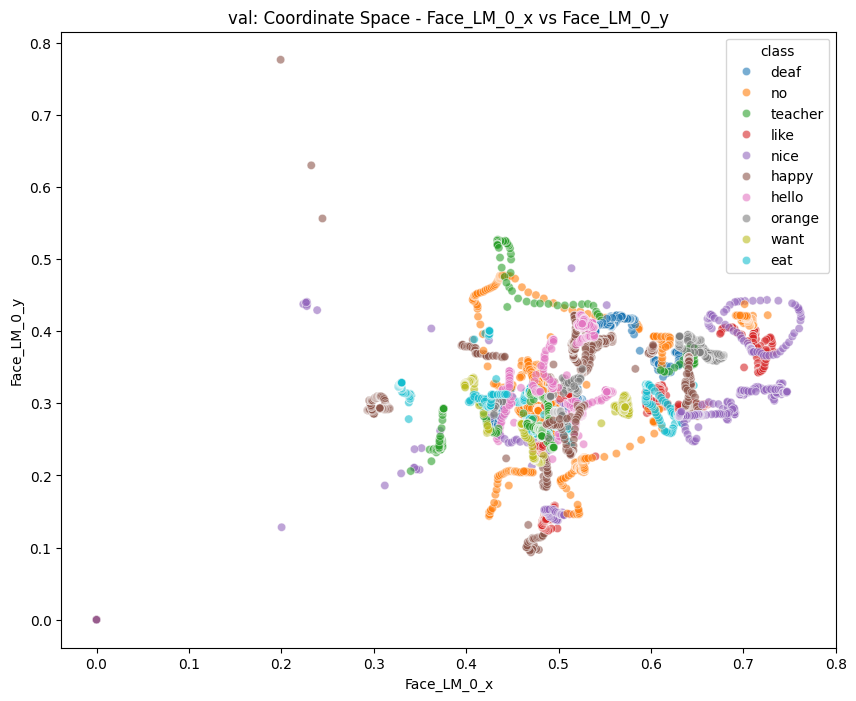

Found 0 outliers (0.00%)

Analyzing test dataset...


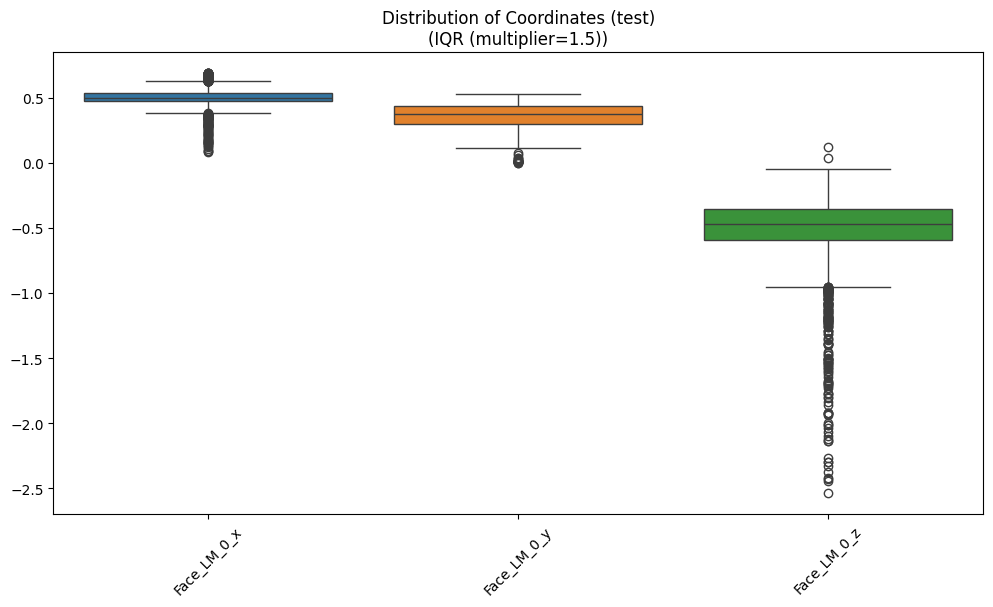

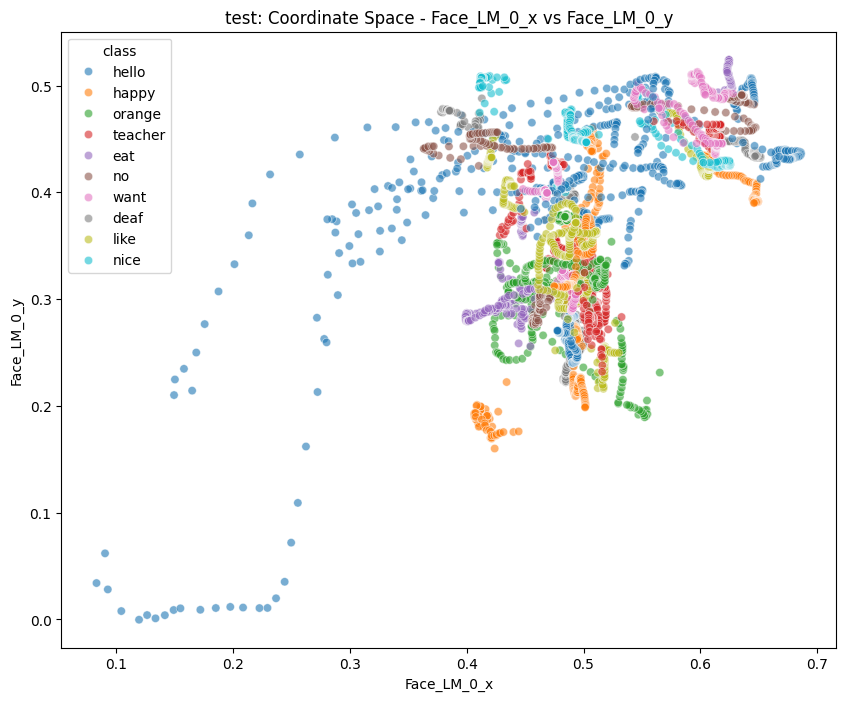

Found 0 outliers (0.00%)

Final Summary:

TRAIN Dataset:
- Method: IQR (multiplier=1.5)
- Total rows: 27388
- Outliers detected: 0 (0.00%)

Outliers by class:
  deaf: 0 (0.00%)
  eat: 0 (0.00%)
  happy: 0 (0.00%)
  hello: 0 (0.00%)
  like: 0 (0.00%)
  nice: 0 (0.00%)
  no: 0 (0.00%)
  orange: 0 (0.00%)
  teacher: 0 (0.00%)
  want: 0 (0.00%)

VAL Dataset:
- Method: IQR (multiplier=1.5)
- Total rows: 4833
- Outliers detected: 0 (0.00%)

Outliers by class:
  deaf: 0 (0.00%)
  eat: 0 (0.00%)
  happy: 0 (0.00%)
  hello: 0 (0.00%)
  like: 0 (0.00%)
  nice: 0 (0.00%)
  no: 0 (0.00%)
  orange: 0 (0.00%)
  teacher: 0 (0.00%)
  want: 0 (0.00%)

TEST Dataset:
- Method: IQR (multiplier=1.5)
- Total rows: 4341
- Outliers detected: 0 (0.00%)

Outliers by class:
  deaf: 0 (0.00%)
  eat: 0 (0.00%)
  happy: 0 (0.00%)
  hello: 0 (0.00%)
  like: 0 (0.00%)
  nice: 0 (0.00%)
  no: 0 (0.00%)
  orange: 0 (0.00%)
  teacher: 0 (0.00%)
  want: 0 (0.00%)


In [33]:
# Example usage with multiple DataFrames
datasets = {
    "train": train_df,
    "val": val_df,
    "test": test_df
}

all_results = {}

for name, df in datasets.items():
    print(f"\nAnalyzing {name} dataset...")
    result = detect_outliers(
        df=df,
        name=name,
        method='iqr',
        class_column='class',
        output_plots=True,
        save_outliers=True
    )
    all_results[name] = result['results']
    
    # Print summary
    print(f"Found {result['results']['outliers_detected']} outliers ({result['results']['outliers_percentage']:.2f}%)")
    
    # Optionally inspect outliers DataFrame
    # display(result['outliers_df'].head())

# Print comprehensive results
print("\nFinal Summary:")
for name, res in all_results.items():
    print(f"\n{name.upper()} Dataset:")
    print(f"- Method: {res['method']}")
    print(f"- Total rows: {res['total_rows']}")
    print(f"- Outliers detected: {res['outliers_detected']} ({res['outliers_percentage']:.2f}%)")
    
    if res['outliers_by_class']:
        print("\nOutliers by class:")
        for cls, cls_data in res['outliers_by_class'].items():
            print(f"  {cls}: {cls_data['count']} ({cls_data['percentage']:.2f}%)")

In [35]:
def detect_outliers_all_columns(df, name="dataset", method='iqr', class_column='class', 
                               output_plots=False, save_outliers=False, 
                               ignore_zero_columns=True, z_threshold=3, iqr_multiplier=1.5,
                               exclude_columns=None):
    """
    Detect outliers in all numeric columns of a DataFrame.
    
    Parameters:
    - df (DataFrame): Input DataFrame containing the data
    - name (str): Name of the dataset (for reporting)
    - method (str): 'iqr', 'zscore', or 'range' (default: 'iqr')
    - class_column (str): Column name for grouping (default: 'class')
    - output_plots (bool): Whether to generate visualizations (default: False)
    - save_outliers (bool): Whether to save outliers to CSV (default: False)
    - ignore_zero_columns (bool): Whether to ignore all-zero columns (default: True)
    - z_threshold (float): Z-score threshold (default: 3)
    - iqr_multiplier (float): IQR multiplier (default: 1.5)
    - exclude_columns (list): Columns to exclude from analysis (default: None)
    
    Returns:
    - dict: Dictionary containing outliers DataFrame and summary statistics
    """
    
    # Identify numeric columns and exclude specified columns
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if exclude_columns:
        numeric_cols = [col for col in numeric_cols if col not in exclude_columns]
    if class_column in numeric_cols:
        numeric_cols.remove(class_column)
    
    # Ignore all-zero columns if requested
    if ignore_zero_columns:
        non_zero_cols = df[numeric_cols].columns[(df[numeric_cols] != 0).any()]
        numeric_cols = [col for col in numeric_cols if col in non_zero_cols]
    
    results = {
        'dataset_name': name,
        'total_rows': len(df),
        'analyzed_columns': numeric_cols,
        'outliers_detected': None,
        'outliers_by_class': {}
    }
    
    # Method 1: Range-based detection
    if method == 'range':
        outliers = df[(df[numeric_cols] < 0) | (df[numeric_cols] > 1)]
        results['method'] = 'Range (0-1)'
    
    # Method 2: Z-score detection
    elif method == 'zscore':
        z_scores = df[numeric_cols].apply(zscore)
        outliers = df[(z_scores.abs() > z_threshold).any(axis=1)]
        results['method'] = f'Z-score (threshold={z_threshold})'
    
    # Method 3: IQR detection (default)
    else:
        Q1 = df[numeric_cols].quantile(0.25)
        Q3 = df[numeric_cols].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        outliers = df[((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]
        results['method'] = f'IQR (multiplier={iqr_multiplier})'
    
    results['outliers_detected'] = len(outliers)
    results['outliers_percentage'] = (len(outliers) / len(df)) * 100
    
    # Group outliers by class if class column exists
    if class_column in df.columns:
        grouped = df.groupby(class_column)
        for group_name, group in grouped:
            if method == 'zscore':
                z_scores = group[numeric_cols].apply(zscore)
                class_outliers = group[(z_scores.abs() > z_threshold).any(axis=1)]
            else:
                Q1 = group[numeric_cols].quantile(0.25)
                Q3 = group[numeric_cols].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - iqr_multiplier * IQR
                upper_bound = Q3 + iqr_multiplier * IQR
                class_outliers = group[((group[numeric_cols] < lower_bound) | 
                                      (group[numeric_cols] > upper_bound)).any(axis=1)]
            
            results['outliers_by_class'][group_name] = {
                'count': len(class_outliers),
                'percentage': (len(class_outliers) / len(group)) * 100,
                'example_indices': class_outliers.head(3).index.tolist()
            }
    
    # Generate visualizations
    if output_plots and numeric_cols:
        # Boxplot grid for first 6 columns
        plt.figure(figsize=(16, 8))
        for i, col in enumerate(numeric_cols[:6], 1):
            plt.subplot(2, 3, i)
            sns.boxplot(x=df[col])
            plt.title(f'{col}\n({results["method"]})')
            plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Pairplot for first 3 numeric columns
        if len(numeric_cols) >= 3:
            sns.pairplot(df[numeric_cols[:3] + [class_column] if class_column in df.columns else numeric_cols[:3]],
                        hue=class_column if class_column in df.columns else None,
                        diag_kind='kde')
            plt.suptitle(f'{name}: Pairwise Relationships', y=1.02)
            plt.show()
    
    # Save outliers to file
    if save_outliers and len(outliers) > 0:
        output_file = f"{name}_outliers_{method}.csv"
        outliers.to_csv(output_file, index=False)
        results['output_file'] = output_file
    
    return {'results': results, 'outliers_df': outliers}

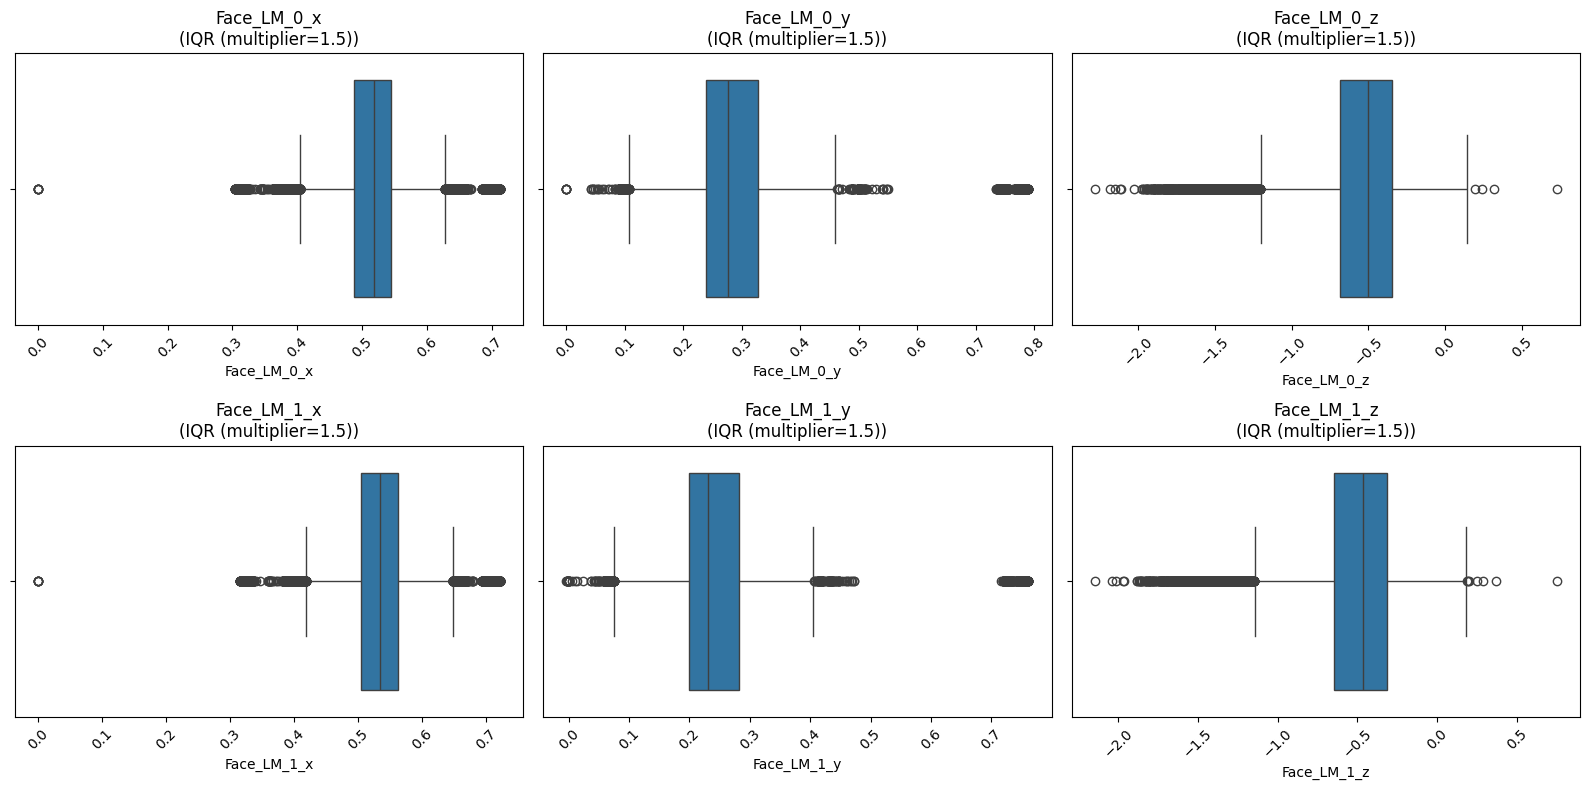

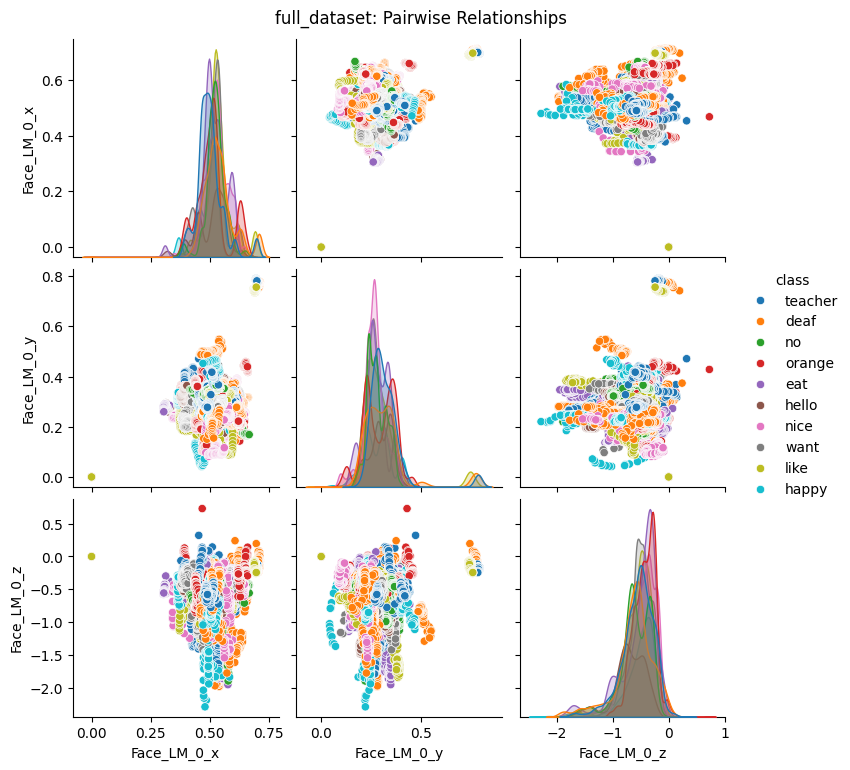

Total outliers detected: 14448
Outlier percentage: 52.75%


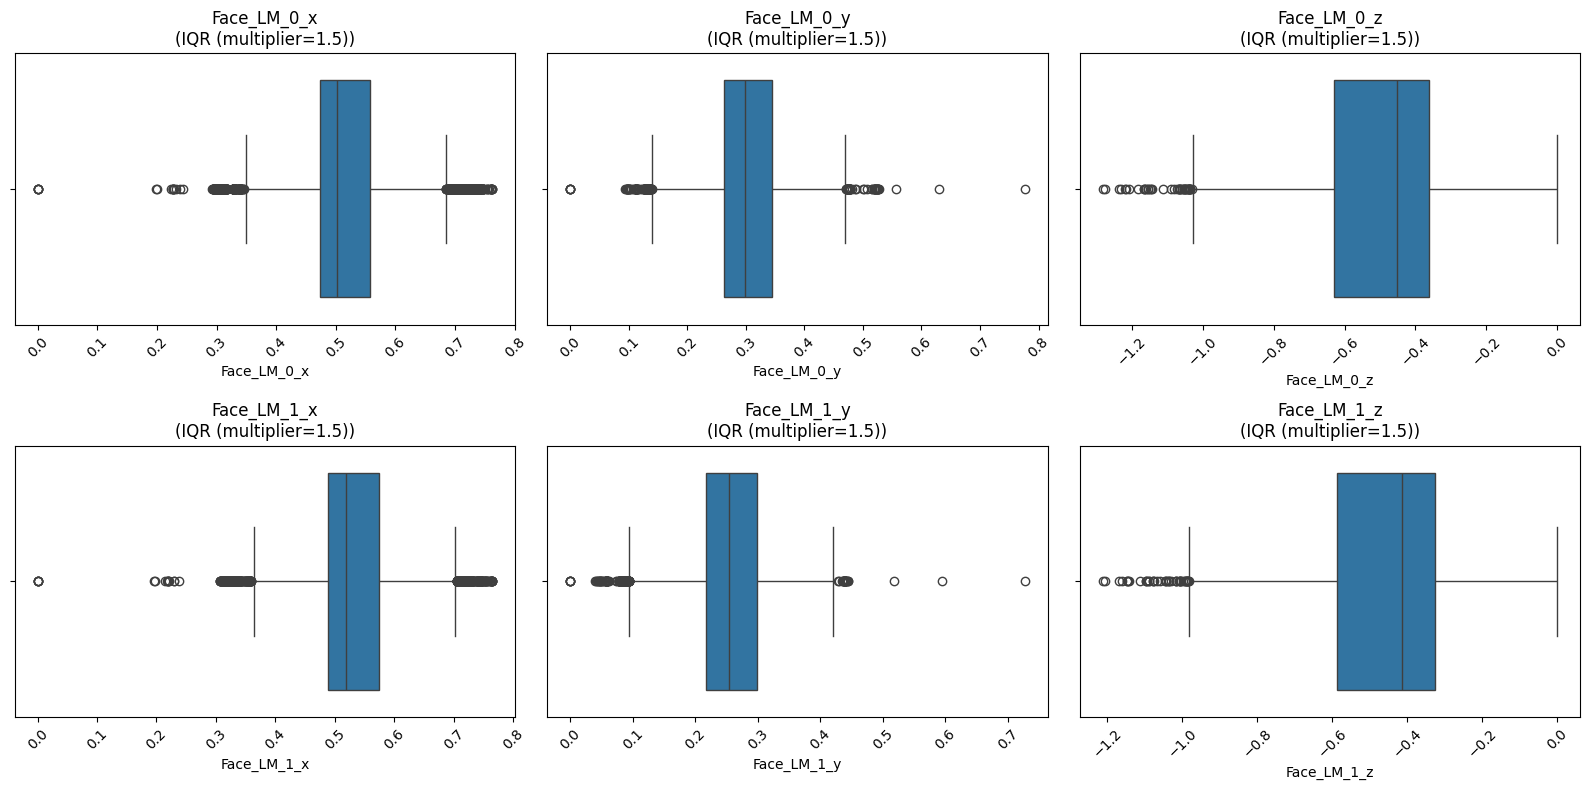

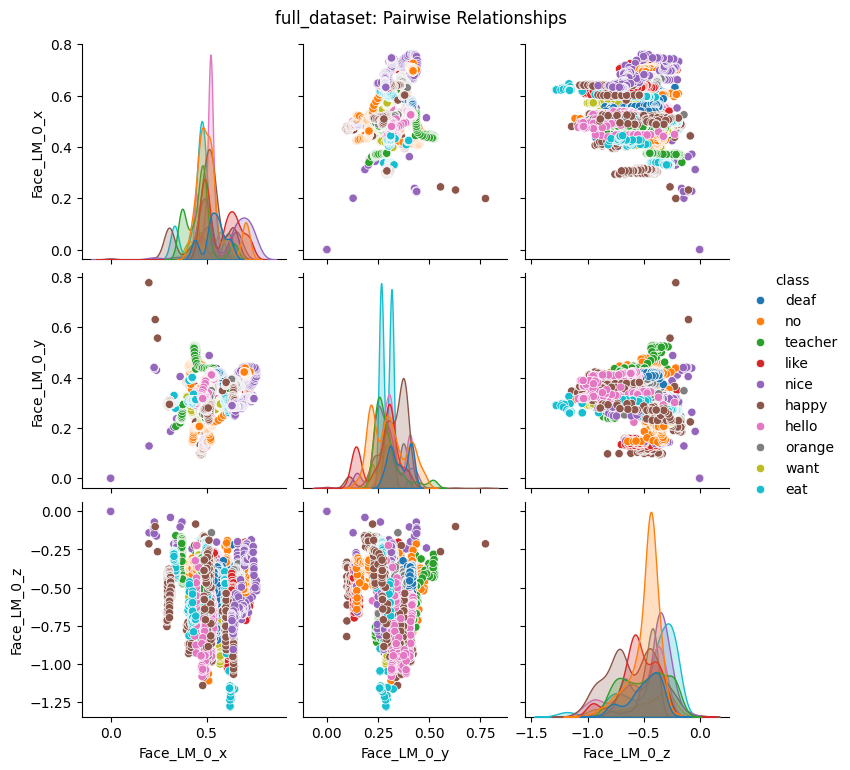

Total outliers detected: 2685
Outlier percentage: 55.56%


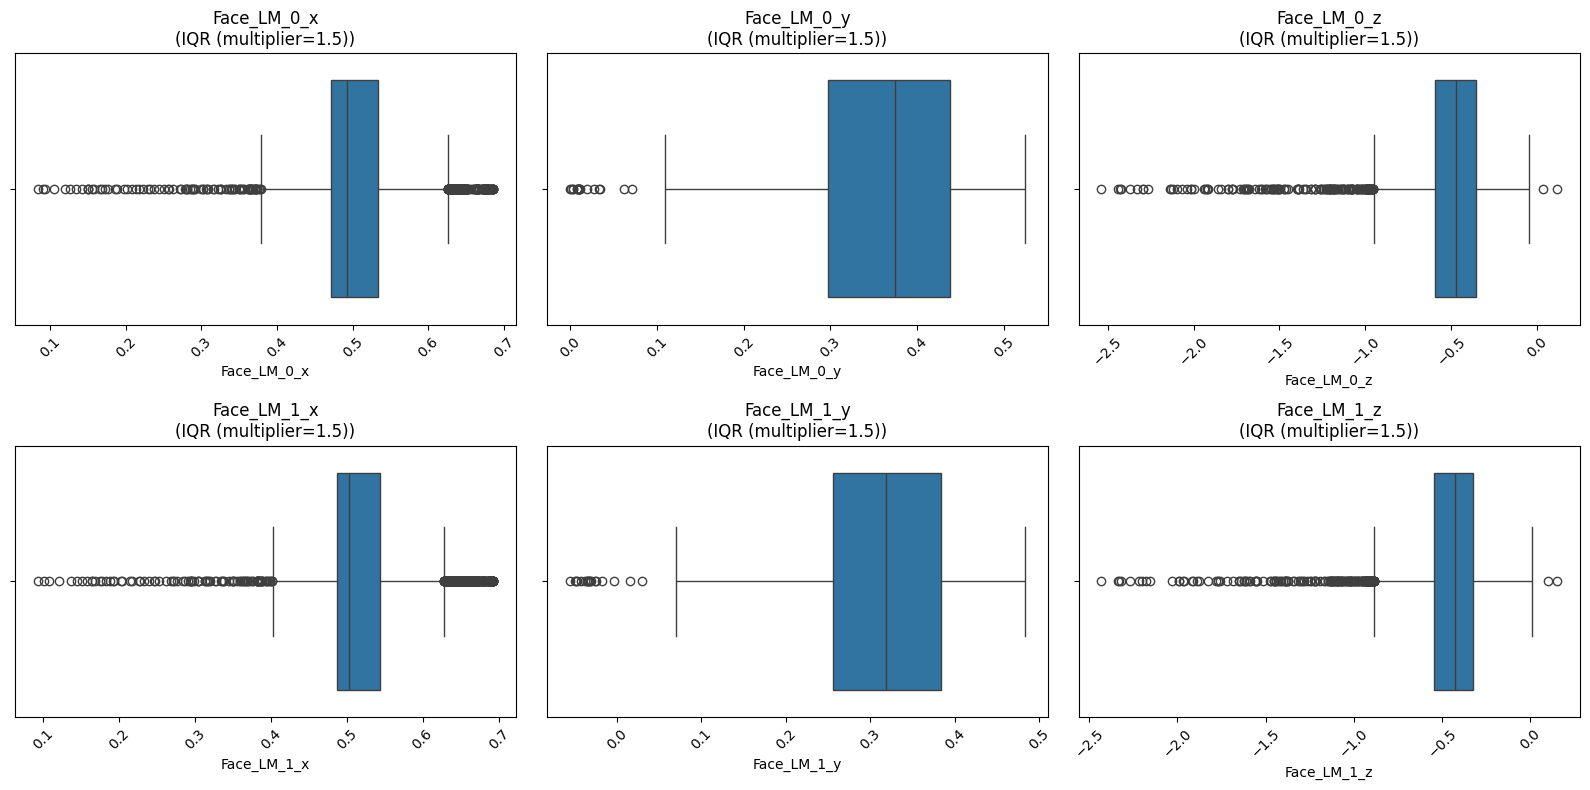

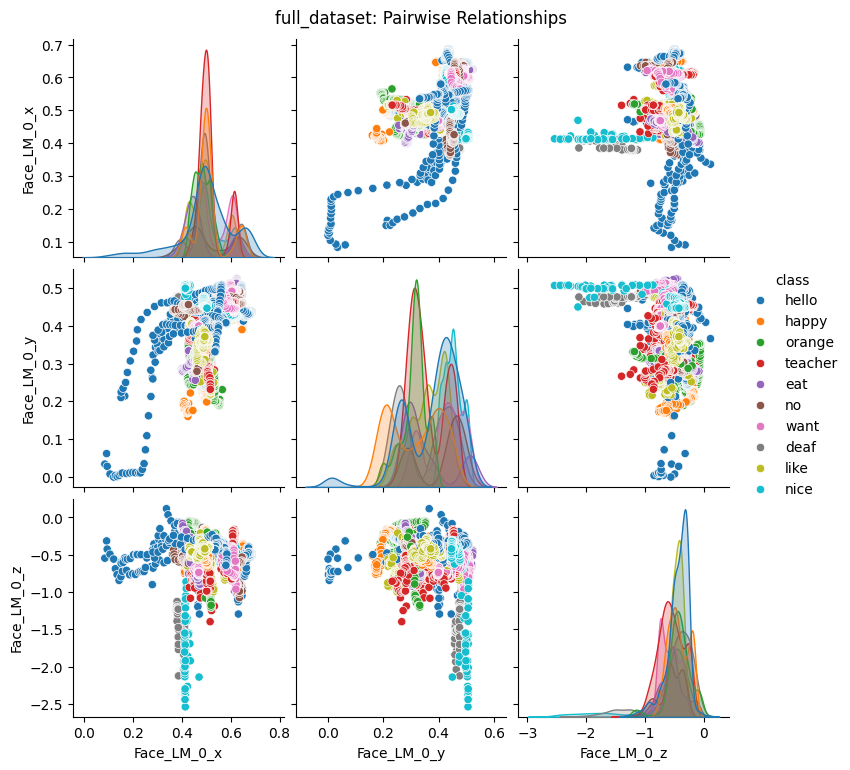

Total outliers detected: 1924
Outlier percentage: 44.32%


In [42]:


for i in dfs:

    # Analyze all numeric columns except 'frame'
    results = detect_outliers_all_columns(
        df=i,
        name="full_dataset",
        method='iqr',
        exclude_columns=[ 'frame'],
        output_plots=True,
        save_outliers=True
    )
    
    # Show summary
    print(f"Total outliers detected: {results['results']['outliers_detected']}")
    print(f"Outlier percentage: {results['results']['outliers_percentage']:.2f}%")
    
    # Access full outliers DataFrame
    outliers_df = results['outliers_df']
    print("="*200)

In [41]:
train_df.shape

(27388, 168)